[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


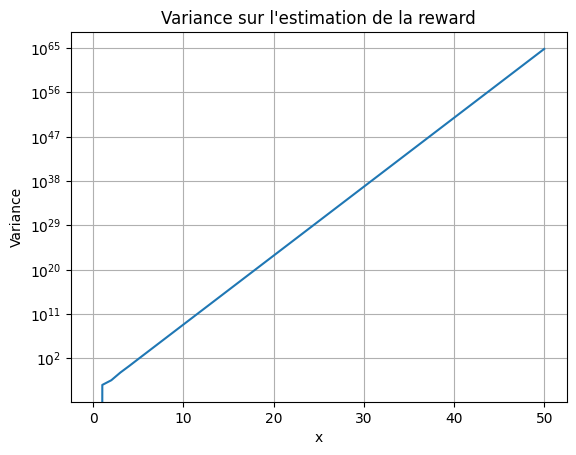

In [12]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0,50,51)
q = 0.5 * np.ones(51) #* np.power(-1, np.arange(51))
print(q)
def variance(kappa, q, sigma, x):
    v = np.zeros_like(x)
    for i in range(0, len(x)):
        sqr = np.zeros_like(x)
        for j in range(i):
            for k in range(i - j):
                sqr[i] += (-1)**(k+1) * q[k] * kappa**(k-1) * sigma 
        v[i] = sqr[i]**2
    return v

v = variance(5.0, q, 0.2, x)

plt.plot(x, v)
plt.yscale('log')             # échelle logarithmique pour l'axe des ordonnées
plt.xlabel('x')
plt.ylabel('Variance')
plt.title('Variance sur l\'estimation de la reward')
plt.grid()
plt.show()

<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
C:\Users\enzom\AppData\Local\Temp\ipykernel_21676\3059052782.py:55: SyntaxWarning: invalid escape sequence '\m'
  ax_hr.set_ylabel('Hit Ratio  $\mathrm{HR}_t$', fontsize=11)
C:\Users\enzom\AppData\Local\Temp\ipykernel_21676\3059052782.py:63: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_hr.show()
C:\Users\enzom\AppData\Local\Temp\ipykernel_21676\3059052782.py:80: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_I.show()


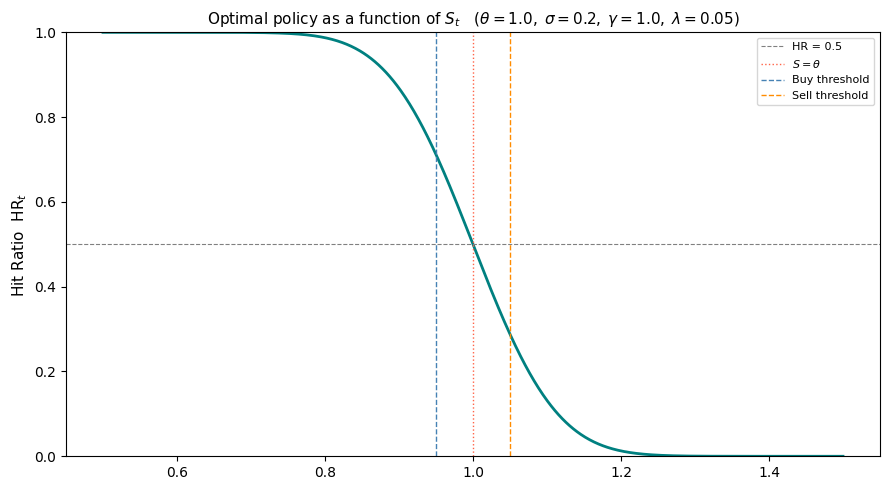

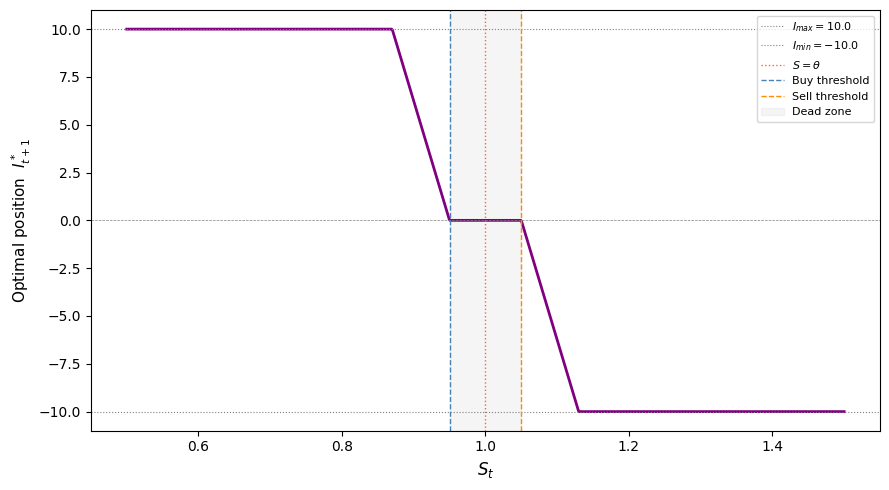

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ── Fixed parameters ──────────────────────────────────────────────────────────
dt     = 0.2
kappa  = 5.0
sigma  = 0.2
lam    = 0.05
gamma  = 1.0
I_max  = 10.0
I_min  = -10.0

theta  = 1.0          # fixed regime mean
I_t    = 0.0          # current position (fixed for the plot)

# ── Grid on S_t ───────────────────────────────────────────────────────────────
S_grid = np.linspace(0.5, 1.5, 1000)

# ── Compute optimal ΔI and I* for each S_t ───────────────────────────────────
denom  = gamma * sigma**2 * dt

dI_star = np.zeros_like(S_grid)
I_star  = np.zeros_like(S_grid)
HR      = np.zeros_like(S_grid)

for i, S in enumerate(S_grid):
    mu        = kappa * (theta - S) * dt
    hr        = norm.cdf(mu / (sigma * np.sqrt(dt)))
    HR[i]     = hr
    mu_tilde  = sigma * np.sqrt(dt) * norm.ppf(hr)   # == mu

    if mu_tilde > lam:
        dI = (mu_tilde - lam) / denom
    elif mu_tilde < -lam:
        dI = (mu_tilde + lam) / denom
    else:
        dI = 0.0

    I_star[i]  = np.clip(I_t + dI, I_min, I_max)
    dI_star[i] = I_star[i] - I_t

# ── Thresholds on S where |mu| = lambda ───────────────────────────────────────
# mu = kappa*(theta - S)*dt = ±lam  =>  S = theta ∓ lam/(kappa*dt)
S_upper = theta - lam / (kappa * dt)   # mu =  lam  (buy threshold)
S_lower = theta + lam / (kappa * dt)   # mu = -lam  (sell threshold)

# ── Plot Hit ratio on its own figure ─────────────────────────────────────────
fig_hr, ax_hr = plt.subplots(figsize=(9,5))
ax_hr.plot(S_grid, HR, color='teal', lw=2)
ax_hr.axhline(0.5, color='grey', lw=0.8, linestyle='--', label='HR = 0.5')
ax_hr.axvline(theta,   color='tomato', lw=1.0, linestyle=':', label=r'$S=\theta$')
ax_hr.axvline(S_upper, color='steelblue', lw=1.0, linestyle='--', label=r'Buy threshold')
ax_hr.axvline(S_lower, color='darkorange', lw=1.0, linestyle='--', label=r'Sell threshold')
ax_hr.set_ylabel('Hit Ratio  $\mathrm{HR}_t$', fontsize=11)
ax_hr.set_title(rf'Optimal policy as a function of $S_t$'
             rf'   ($\theta={theta},\;\sigma={sigma},\;\gamma={gamma},\;\lambda={lam}$)',
             fontsize=11)
ax_hr.legend(fontsize=8)
ax_hr.set_ylim(0, 1)
fig_hr.tight_layout()
fig_hr.savefig('hitratio_vs_St.png', dpi=150, bbox_inches='tight')
fig_hr.show()

# ── Plot optimal position on a second figure ──────────────────────────────────
fig_I, ax_I = plt.subplots(figsize=(9,5))
ax_I.plot(S_grid, I_star, color='purple', lw=2)
ax_I.axhline(I_max, color='grey', lw=0.8, linestyle=':', label=f'$I_{{max}}={I_max}$')
ax_I.axhline(I_min, color='grey', lw=0.8, linestyle=':', label=f'$I_{{min}}={I_min}$')
ax_I.axhline(0,     color='grey', lw=0.5, linestyle='--')
ax_I.axvline(theta,   color='tomato',     lw=1.0, linestyle=':',  label=r'$S=\theta$')
ax_I.axvline(S_upper, color='steelblue',  lw=1.0, linestyle='--', label='Buy threshold')
ax_I.axvline(S_lower, color='darkorange', lw=1.0, linestyle='--', label='Sell threshold')
ax_I.axvspan(S_upper, S_lower, alpha=0.08, color='grey', label='Dead zone')
ax_I.set_xlabel('$S_t$', fontsize=12)
ax_I.set_ylabel(r'Optimal position  $I^*_{t+1}$', fontsize=11)
ax_I.legend(fontsize=8)
fig_I.tight_layout()
fig_I.savefig('policy_vs_St.png', dpi=150, bbox_inches='tight')
fig_I.show()